In [1]:
!pip install pydmd

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.7/152.7 kB 6.3 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 41699385750.64799. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


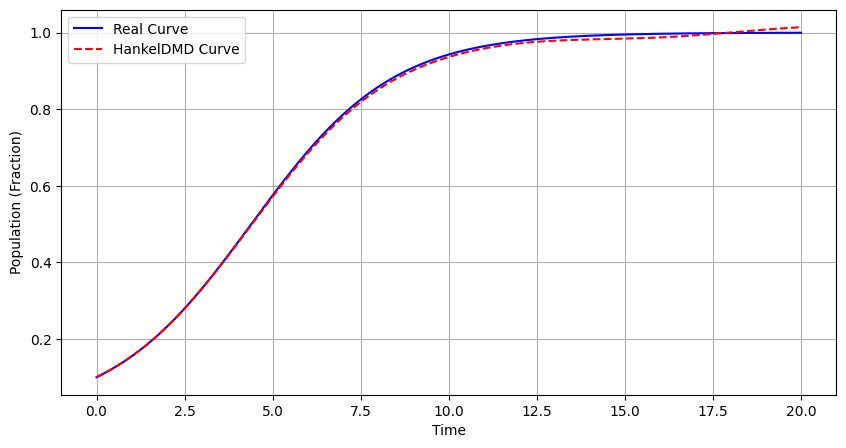

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# Initialize parameters and time
kappa = 0.5
x0 = 0.1
t = np.linspace(0, 20, 401)
dt = t[1] - t[0]

# Define the vector field for the logistic equation
def f(x, t):
    dxdt = kappa * x * (1 - x)
    return dxdt

# Solve numerically the ODE
sol = odeint(f, [x0], t)
x = sol.T

from pydmd import DMD, HankelDMD
from pydmd.preprocessing import hankel_preprocessing
from pydmd.plotter import plot_eigs, plot_summary

d = 16 # Number of Delays
# Apply Hankel DMD
hankel_dmd = HankelDMD(svd_rank=6, d=d)
hankel_dmd.fit(x)

# Plot original and reconstructed state
plt.figure(figsize=(10, 5))
plt.plot(t, x[0], color='blue', label="Real Curve")
plt.plot(t, hankel_dmd.reconstructed_data[0], '--', color='red', label="HankelDMD Curve")
plt.legend()
plt.xlabel('Time')
plt.ylabel('Population (Fraction)')
plt.legend()
plt.grid(True)
plt.savefig(f"comparison_state_dmd.jpeg")
plt.show()

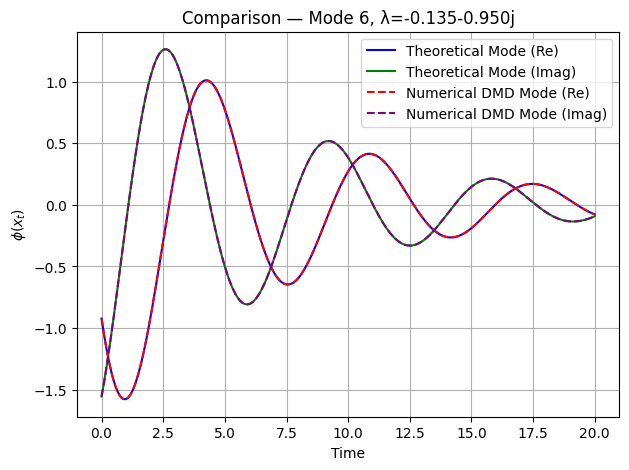

In [3]:
# =============================================================================
# ======================== COMPARISON OF THE MODES ============================
# =============================================================================
# Theoretical Eigenfunction for the logistic system
def phi(x, lam, kappa):
    z = x / (1 - x)
    return np.power(z.astype(complex), lam / kappa)

# Continuous eigenvalues
eig_lambdas = np.log(hankel_dmd.eigs) / dt

idx = 0  # Number of the mode
xt = x[0] # The evolution of x
lam = eig_lambdas[idx]
phi_num = hankel_dmd.dynamics[idx, :]  # Numerical evolution of b_j * mu_j^k for different k's
phi_teo = phi(xt, lam, kappa) # Theoretical evolution of the Eigenfunction of the system

# Normalize the values of phi_num (the initial value)
phi_num *= phi_teo[0] / phi_num[0]

plt.figure(figsize=(7,5))
plt.plot(t, phi_teo.real, label='Theoretical Mode (Re)', color='blue')
plt.plot(t, phi_teo.imag, label='Theoretical Mode (Imag)', color='green')
plt.plot(t, phi_num.real, '--', label=f'Numerical DMD Mode (Re)', color='red')
plt.plot(t, phi_num.imag, '--', label=f'Numerical DMD Mode (Imag)', color='purple')
plt.xlabel('Time')
plt.ylabel(r'$\phi(x_t)$')
plt.legend()
plt.grid(True)
plt.title(f'Comparison — Mode {idx+1}, λ={lam:.3f}')
plt.savefig(f"comparison_modes{idx+1}.jpeg")
plt.show()

In [4]:
hankel_dmd.operator.as_numpy_array

array([[ 1.00185916e+00, -2.16911518e-01, -5.57322255e-02,
         3.53956065e-01, -2.54354418e-01, -6.04980729e-01],
       [ 9.10111579e-05,  9.99556385e-01,  4.86609373e-01,
        -1.78088723e-01,  7.48038921e-01,  6.98191290e-01],
       [-4.78217207e-07, -3.44763652e-04,  9.97108389e-01,
        -7.48640664e-01,  3.71157928e-01,  1.17290083e+00],
       [-2.06048562e-08,  1.73551079e-06,  5.78556101e-04,
         9.93963951e-01, -1.01574923e+00, -6.31021987e-01],
       [-1.50567325e-10, -7.07014755e-08, -4.38388420e-06,
         8.09998675e-04,  9.90606037e-01,  1.27960274e+00],
       [ 1.05543076e-11, -1.23846303e-09, -1.29831666e-07,
         6.99008869e-06, -1.04821890e-03,  9.80319997e-01]])

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


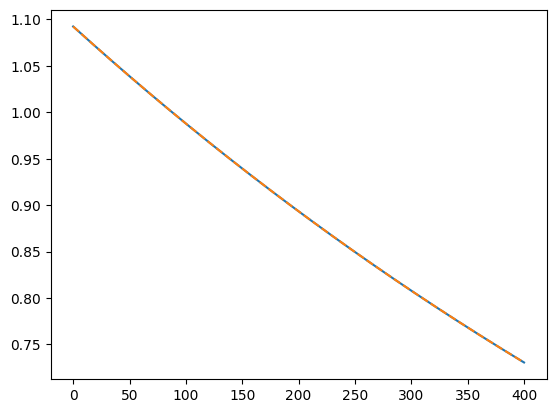

In [41]:
idx = 0  # Number of the mode
xt = x[0] # The evolution of x
lam = eig_lambdas[idx]
phi_num = hankel_dmd.dynamics[idx, :]  # Numerical evolution of b_j * mu_j^k for different k's
phi_teo = phi(xt, lam, kappa) # Theoretical evolution of the Eigenfunction of the system
phi_num *= phi_teo[0] / phi_num[0]

dynamics_manual = np.power(np.exp(1).astype(complex), lam * t)
dynamics_manual = dynamics_manual * phi_num[0].astype(complex) / dynamics_manual[0].astype(complex)

plt.plot(dynamics_manual.real)
plt.plot(phi_num, '--')

In [49]:
hankel_dmd.amplitudes

array([-7.75437825-2.70477552e-12j,  6.85805779+2.92168251e-12j,
       -0.23267575+3.90022679e-01j, -0.23267575-3.90022679e-01j,
        0.02016818-4.68222590e-04j,  0.02016818+4.68222590e-04j])

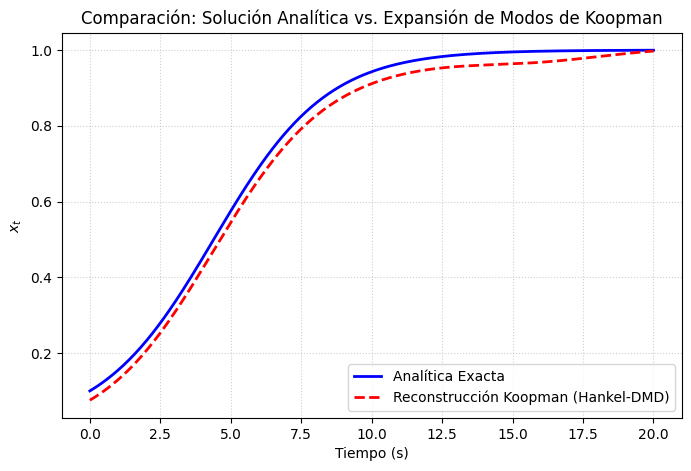

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuración del tiempo (mismos parámetros de tu simulación)
t = np.linspace(0, 20, 400)

# 2. Solución analítica exacta de la ecuación logística
kappa = 0.5
x0 = 0.1
x_analytical = x0 / (x0 + (1 - x0) * np.exp(-kappa * t))

# 3. Parámetros identificados por Hankel-DMD (aproximados a 2 decimales)
lambdas = np.array([-0.02, -0.09, -0.15 + 0.42j, -0.15 - 0.42j, -0.14 + 0.95j, -0.14 - 0.95j])
bs = np.array([-7.75, 6.86, -0.23 + 0.39j, -0.23 - 0.39j, 0.02, 0.02])
phis_1 = np.array([-0.25, -0.26, 0.26 - 0.04j, 0.26 + 0.04j, 0.25 - 0.09j, 0.25 + 0.09j])

# 4. Reconstrucción del estado x_t usando la sumatoria de los 6 modos
# Evaluamos cada modo de forma vectorial sobre el vector de tiempo 't'
x_koopman = np.zeros_like(t, dtype=complex)
for j in range(6):
    x_koopman += bs[j] * np.exp(lambdas[j] * t) * phis_1[j]

# Nos quedamos con la parte real (la parte imaginaria se cancela por los conjugados)
x_koopman = np.real(x_koopman)

# 5. Graficar la comparación
plt.figure(figsize=(8, 5))
plt.plot(t, x_analytical, label='Analítica Exacta', color='blue', linewidth=2)
plt.plot(t, x_koopman, '--', label='Reconstrucción Koopman (Hankel-DMD)', color='red', linewidth=2)
plt.title('Comparación: Solución Analítica vs. Expansión de Modos de Koopman')
plt.xlabel('Tiempo (s)')
plt.ylabel('$x_t$')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()